In [1]:
from dd_math_o3 import DeltaCalculator
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.integrate import quad
import matplotlib.pyplot as plt

In [2]:
if True:
    params = {
        'K': 100,            # Strike price
        'r': 0.05,           # Risk-free rate
        'sigma': 0.158,      # Annual volatility
        'T': 5.0 / 252,      # Time to expiration (~5 trading days)
        'mu': 0.07           # Real-world drift
    }
    
    calculator = DeltaCalculator(**params)
    sigma_moves = np.arange(-4, 4.1, 0.1)
    initial_deltas = [0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
    delta_t = 1/252  # One-day time step
    

In [7]:
if True:    
    # Compute and display the expected delta differences.
    pd.set_option('display.max_columns', 12)
    pd.set_option('display.width', 250)

    df_delta = calculator.simulate_multiple(initial_deltas, sigma_moves, delta_t)
    print("Expected Delta Differences (Interpolated):")
    print(df_delta.head())

Expected Delta Differences (Interpolated):
           Δ₀=0.1 (S₀=97.07)  Δ₀=0.2 (S₀=98.02)  Δ₀=0.4 (S₀=99.31)  Δ₀=0.5 (S₀=99.88)  Δ₀=0.6 (S₀=100.44)  Δ₀=0.8 (S₀=101.76)  Δ₀=0.9 (S₀=102.77)
-4.091337          -0.061734          -0.102281          -0.145261          -0.150630           -0.145753           -0.103418           -0.062758
-4.050218          -0.061734          -0.102281          -0.145261          -0.150630           -0.145753           -0.103418           -0.062753
-4.009099          -0.061734          -0.102281          -0.145261          -0.150630           -0.145753           -0.103413           -0.062748
-3.967980          -0.061734          -0.102281          -0.145261          -0.150629           -0.145750           -0.103408           -0.062741
-3.926861          -0.061734          -0.102281          -0.145260          -0.150626           -0.145746           -0.103401           -0.062734


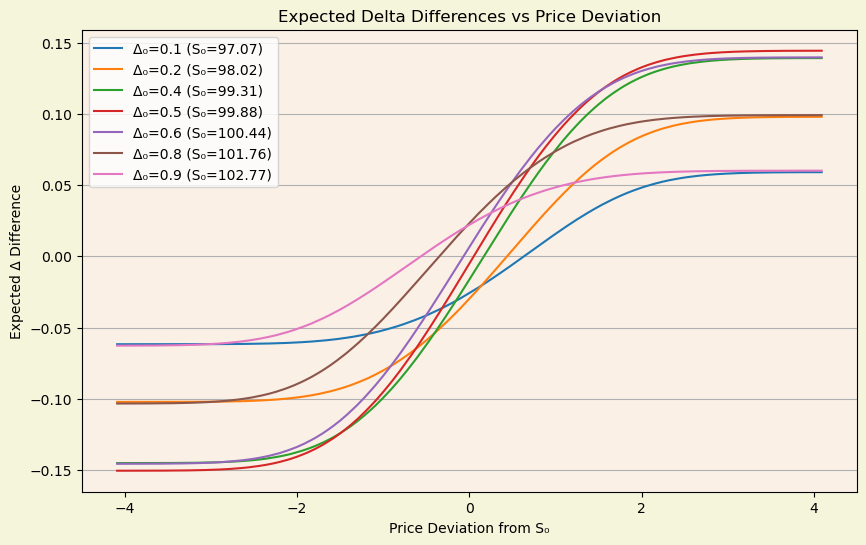

In [4]:
if True:
    # Plot expected delta differences using the default canvas.
    fig, ax = calculator.default_canvas
    df_delta.plot(ax=ax)
    ax.set_xlabel("Price Deviation from S₀")
    ax.set_ylabel("Expected Δ Difference")
    ax.set_title("Expected Delta Differences vs Price Deviation")
    ax.grid(True, axis='y')
    plt.show()

In [8]:
if True:
    summary_data = []
    for d in initial_deltas:
        S0 = calculator._implied_S0(d)
        # Although d is our target delta, we recalc delta for verification:
        delta_val = calculator.delta(S0, calculator.T)
        gamma_val = calculator.gamma(S0, calculator.T)
        charm_val = calculator.initial_charm_change(d, delta_t)
        summary_data.append({
            "Initial Delta": d,
            "Implied S₀": S0,
            "Calculated Delta": delta_val,
            "Initial Gamma": gamma_val,
            "Initial Charm": charm_val
        })
    
    summary_df = pd.DataFrame(summary_data).set_index("Initial Delta")
    print("\nSummary of Initial Greeks and Charm Effect:")
    print(summary_df)


Summary of Initial Greeks and Charm Effect:
               Implied S₀  Calculated Delta  Initial Gamma  Initial Charm
Initial Delta                                                            
0.1             97.067693               0.1       0.081237      -0.027111
0.2             98.022748               0.2       0.128331      -0.033334
0.4             99.314545               0.4       0.174791      -0.018872
0.5             99.876105               0.5       0.179476      -0.005590
0.6            100.440839               0.6       0.172830       0.008228
0.8            101.764504               0.8       0.123612       0.026859
0.9            102.765771               0.9       0.076733       0.024019


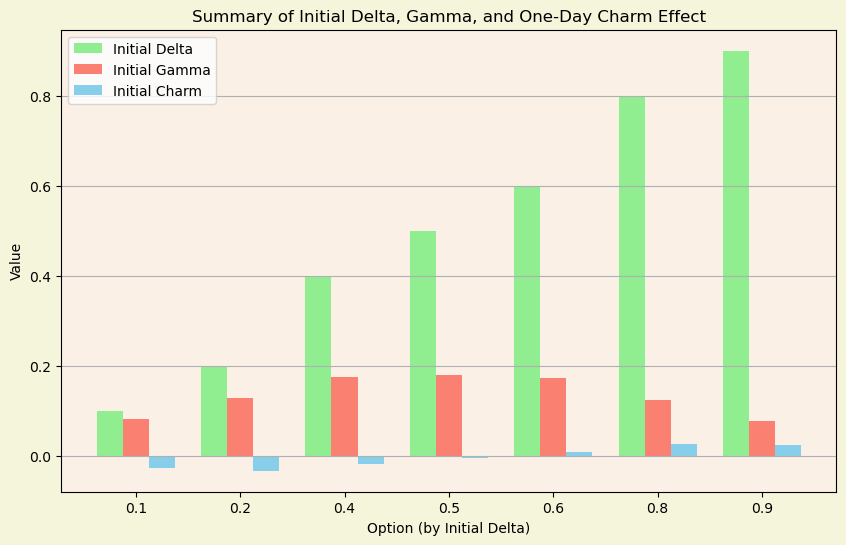

In [6]:
if True:
    # Plot the summary as a bar chart (comparing Delta, Gamma, and Charm).
    fig, ax = calculator.default_canvas
    # For clarity, we plot Gamma and Charm; note that Delta is essentially the input target.
    width = 0.25
    x = np.arange(len(summary_df))
    
    ax.bar(x - width, summary_df["Initial Delta"], width, label="Initial Delta", color='lightgreen')
    ax.bar(x, summary_df["Initial Gamma"], width, label="Initial Gamma", color='salmon')
    ax.bar(x + width, summary_df["Initial Charm"], width, label="Initial Charm", color='skyblue')
    
    ax.set_xlabel("Option (by Initial Delta)")
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df["Initial Delta"].round(2))
    ax.set_ylabel("Value")
    ax.set_title("Summary of Initial Delta, Gamma, and One-Day Charm Effect")
    ax.legend()
    ax.grid(True, axis='y')
    plt.show()

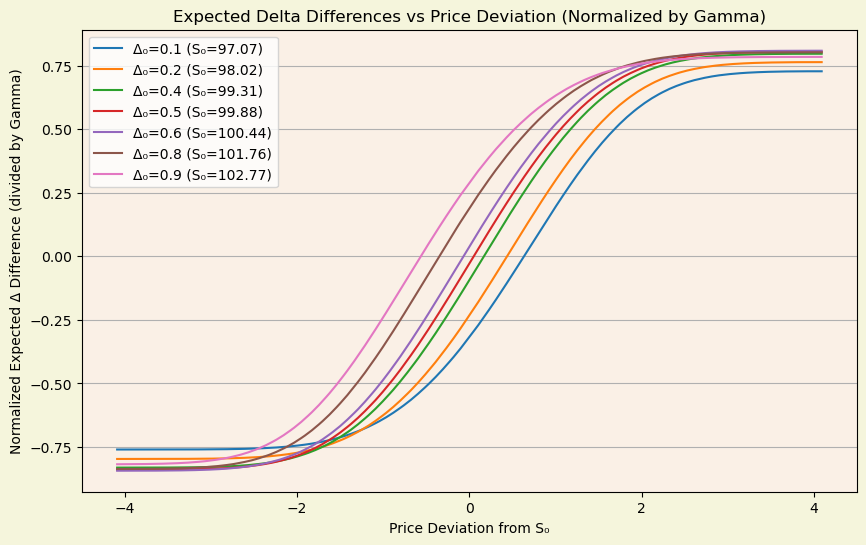

In [9]:
# --- New Section: Normalized Expected Delta Differences by Gamma ---

# Create a copy of the simulated delta differences DataFrame.
normalized_df = df_delta.copy()

# For each initial delta, compute the corresponding gamma and normalize the series.
for d in initial_deltas:
    S0 = calculator._implied_S0(d)
    gamma_val = calculator.gamma(S0, calculator.T)
    col_name = f"Δ₀={d} (S₀={S0:.2f})"
    normalized_df[col_name] = normalized_df[col_name] / gamma_val

# Plot the normalized DataFrame using the default canvas.
fig, ax = calculator.default_canvas
normalized_df.plot(ax=ax)
ax.set_xlabel("Price Deviation from S₀")
ax.set_ylabel("Normalized Expected Δ Difference (divided by Gamma)")
ax.set_title("Expected Delta Differences vs Price Deviation (Normalized by Gamma)")
ax.grid(True, axis='y')
plt.show()